# 01 — Strategy performance (SPY, out-of-sample)

Loads the outputs of `experiments/run_regime_comparison.py configs/comparison_spy.yaml` and visualizes net performance. No core logic here — figures come from `regimelab.plotting`.

All series are **out-of-sample** (walk-forward refits), **net of 5 bps proportional costs**, and — since v3 — flat positions earn the **lagged 13-week T-bill rate** (`^IRX`); Sharpe is computed on excess returns. `hmm2p_bXX_bh` are probability-scaled variants with a no-trade band of XX/100.

In [1]:
import sys
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
from regimelab import plotting

FIG = ROOT / "reports" / "figures"
OUT = ROOT / "experiments" / "outputs" / "comparison_spy"
net = pd.read_csv(OUT / "net_returns.csv", index_col=0, parse_dates=True)
summary = pd.read_csv(OUT / "summary.csv", index_col=0)
net.columns.tolist()

['buy_and_hold',
 'trend_200d',
 'vol20q80_bh',
 'vol20q80_trend',
 'hmm2_bh',
 'hmm2_trend',
 'hmm2p_bh',
 'hmm2p_b05_bh',
 'hmm2p_b10_bh',
 'hmm2p_b20_bh',
 'hmm3_bh',
 'hmm3_trend']

In [2]:
# Headline table at the 5 bps cost level, best Sharpe first.
at5 = summary.loc[summary.index.str.endswith("@5bps")].copy()
at5.index = at5.index.str.replace("@5bps", "")
at5[["ann_return", "ann_volatility", "sharpe", "sortino", "max_drawdown",
     "hit_ratio", "avg_annual_turnover"]].sort_values("sharpe", ascending=False).round(3)

,ann_return,ann_volatility,sharpe,sortino,max_drawdown,hit_ratio,avg_annual_turnover
strategy,,,,,,,
hmm2p_b20_bh,0.088,0.101,0.712,0.986,-0.168,0.564,6.697
vol20q80_bh,0.103,0.128,0.695,0.953,-0.332,0.616,3.414
hmm2_bh,0.093,0.114,0.686,0.949,-0.214,0.631,9.354
hmm2p_b05_bh,0.088,0.107,0.676,0.932,-0.220,0.561,9.980
hmm2p_b10_bh,0.086,0.105,0.675,0.930,-0.210,0.563,8.758
hmm2p_bh,0.088,0.108,0.671,0.925,-0.220,0.553,11.217
hmm2_trend,0.082,0.103,0.648,0.891,-0.172,0.658,7.857
vol20q80_trend,0.085,0.111,0.640,0.874,-0.209,0.648,5.940
hmm3_trend,0.083,0.115,0.597,0.810,-0.209,0.632,6.314


PosixPath('/Users/mohamedryad/Desktop/RegimeLab/reports/figures/spy_wealth.png')

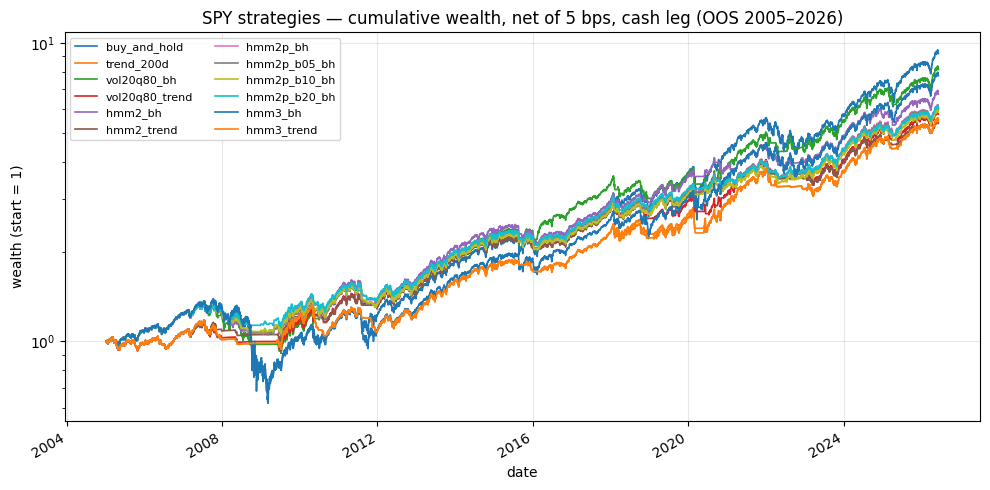

In [3]:
fig = plotting.wealth_curves(net, title="SPY strategies — cumulative wealth, net of 5 bps, cash leg (OOS 2005–2026)")
plotting.save_figure(fig, FIG / "spy_wealth.png")

PosixPath('/Users/mohamedryad/Desktop/RegimeLab/reports/figures/spy_drawdowns.png')

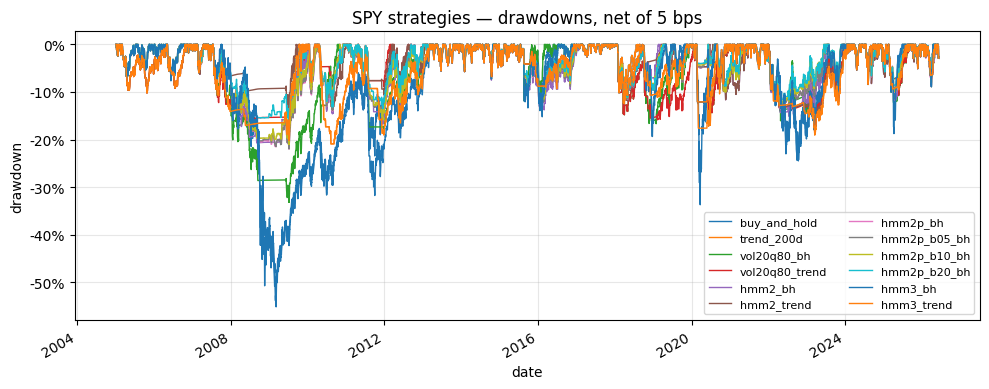

In [4]:
fig = plotting.drawdown_curves(net, title="SPY strategies — drawdowns, net of 5 bps")
plotting.save_figure(fig, FIG / "spy_drawdowns.png")

**Reading.** Gated variants track buy-and-hold in calm markets and step aside in turbulence: similar terminal wealth, much shallower drawdowns (2008-09, 2020, 2022). The cash leg lifts gated returns relative to v2 (flat days earned ~1.9%/yr on average instead of 0). The widest no-trade band (`hmm2p_b20_bh`) achieves the best Sharpe of the HMM family with 40% less turnover than the unbanded version. Statistical significance is examined in notebook 03.